## Data Input

There are 4 alternatives to import wind farm layout data for use within **OptiWindNet**:
- Numpy arrays through OptiWindNet API
- [windIO](https://github.com/IEAWindSystems/windIO) YAML file
- `.yaml` file (OptiWindNet schema)
- `.osm.pbf` file

The formats themselves are specified in [Input formats](../data.md#input-formats); this
notebook shows the loader function for each.

In [1]:
from optiwindnet.svg import svgplot

### Numpy arrays + OptiWindNet API

In [2]:
from itertools import pairwise
import numpy as np

In [3]:
from optiwindnet.interarraylib import L_from_site

In [4]:
# all coordinates are sequences of (x, y) pairs
# if input coordinates are in arrays X and Y, use `np.hstack((X, Y))`
border = np.array( # coordinate sequence defines the polygon, last-first segment implicit
    [[1951, 200], [1951, 1383], [386, 1383], [650, 708], [624, 678],
     [4, 1036], [4, 3], [1152, 3], [917, 819], [957, 854]],
    dtype=float)
# 'obstacles' is an optional location attribute
obstacles = [
    # - obstacles must be strictly inside the border polygon
    # - undefined behavior if obstacles and border overlap
    # first obstacle
    np.array([[1540, 920], [1600, 940], [1600, 1150], [1400, 1200]]),
    # [second obstacle] ...
]
substations = np.array([[696, 1063],], dtype=float)
turbines = np.array(
    [[1940, 279], [1920, 703], [1475, 696], [1839, 1250],
     [1277, 1296], [442, 1359], [737, 435], [1060, 26],
     [522, 176], [87, 35], [184, 417], [71, 878]],
    dtype=float
)
R = substations.shape[0]
T = turbines.shape[0]
border_sizes = np.array([border.shape[0]] +
                        [obstacle.shape[0] for obstacle in obstacles])
B = border_sizes.sum()
obstacle_idxs = np.cumsum(border_sizes) + T

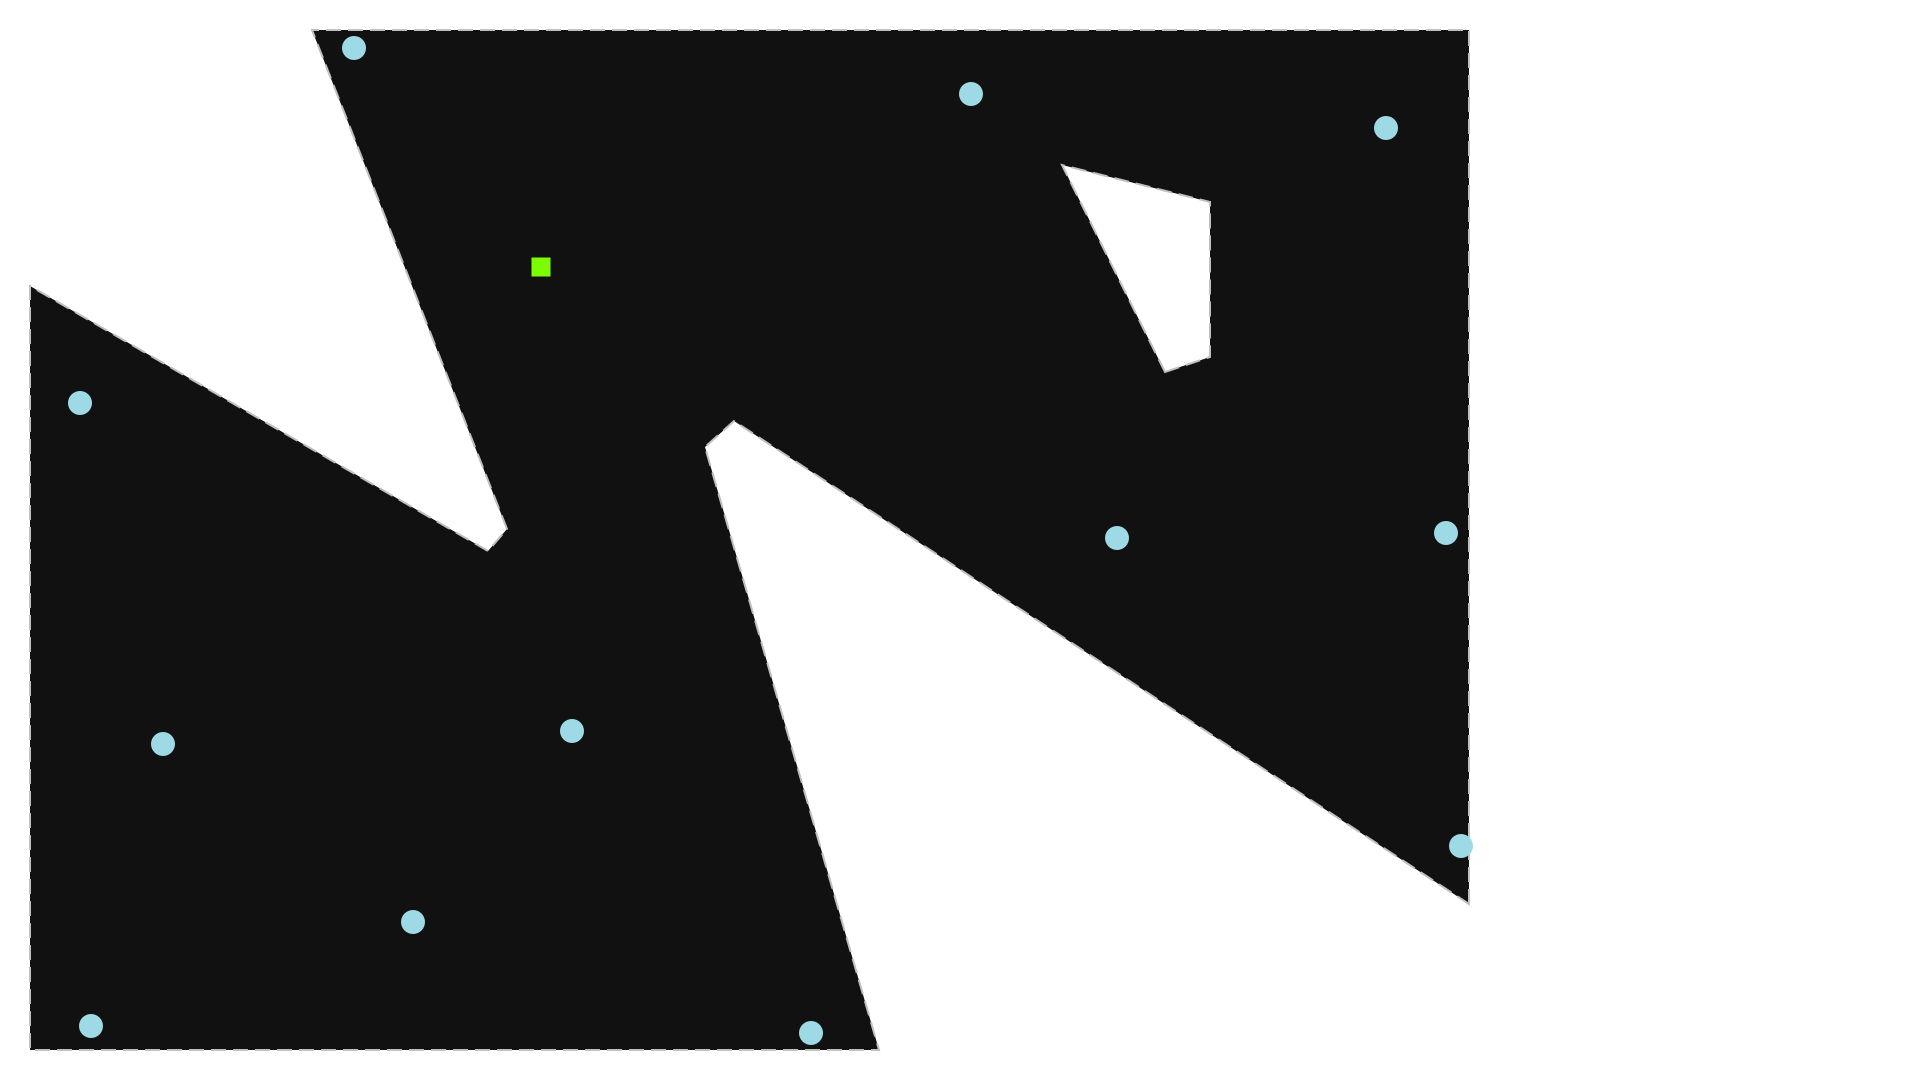

In [5]:
L = L_from_site(
    R=R, T=T, B=B,
    border=np.arange(T, T + border.shape[0]),
    obstacles=[np.arange(a, b) for a, b in pairwise(obstacle_idxs)],
    name='Example Location',
    handle='example',
    VertexC=np.vstack((turbines, border, *obstacles, substations)),
)
svgplot(L)

### windIO YAML file

See [windIO YAML](../data.md#windio-yaml) and the
[windIO documentation](https://ieawindsystems.github.io/windIO/main/index.html) for more
information on that format.

In [6]:
from optiwindnet.importer import L_from_windIO

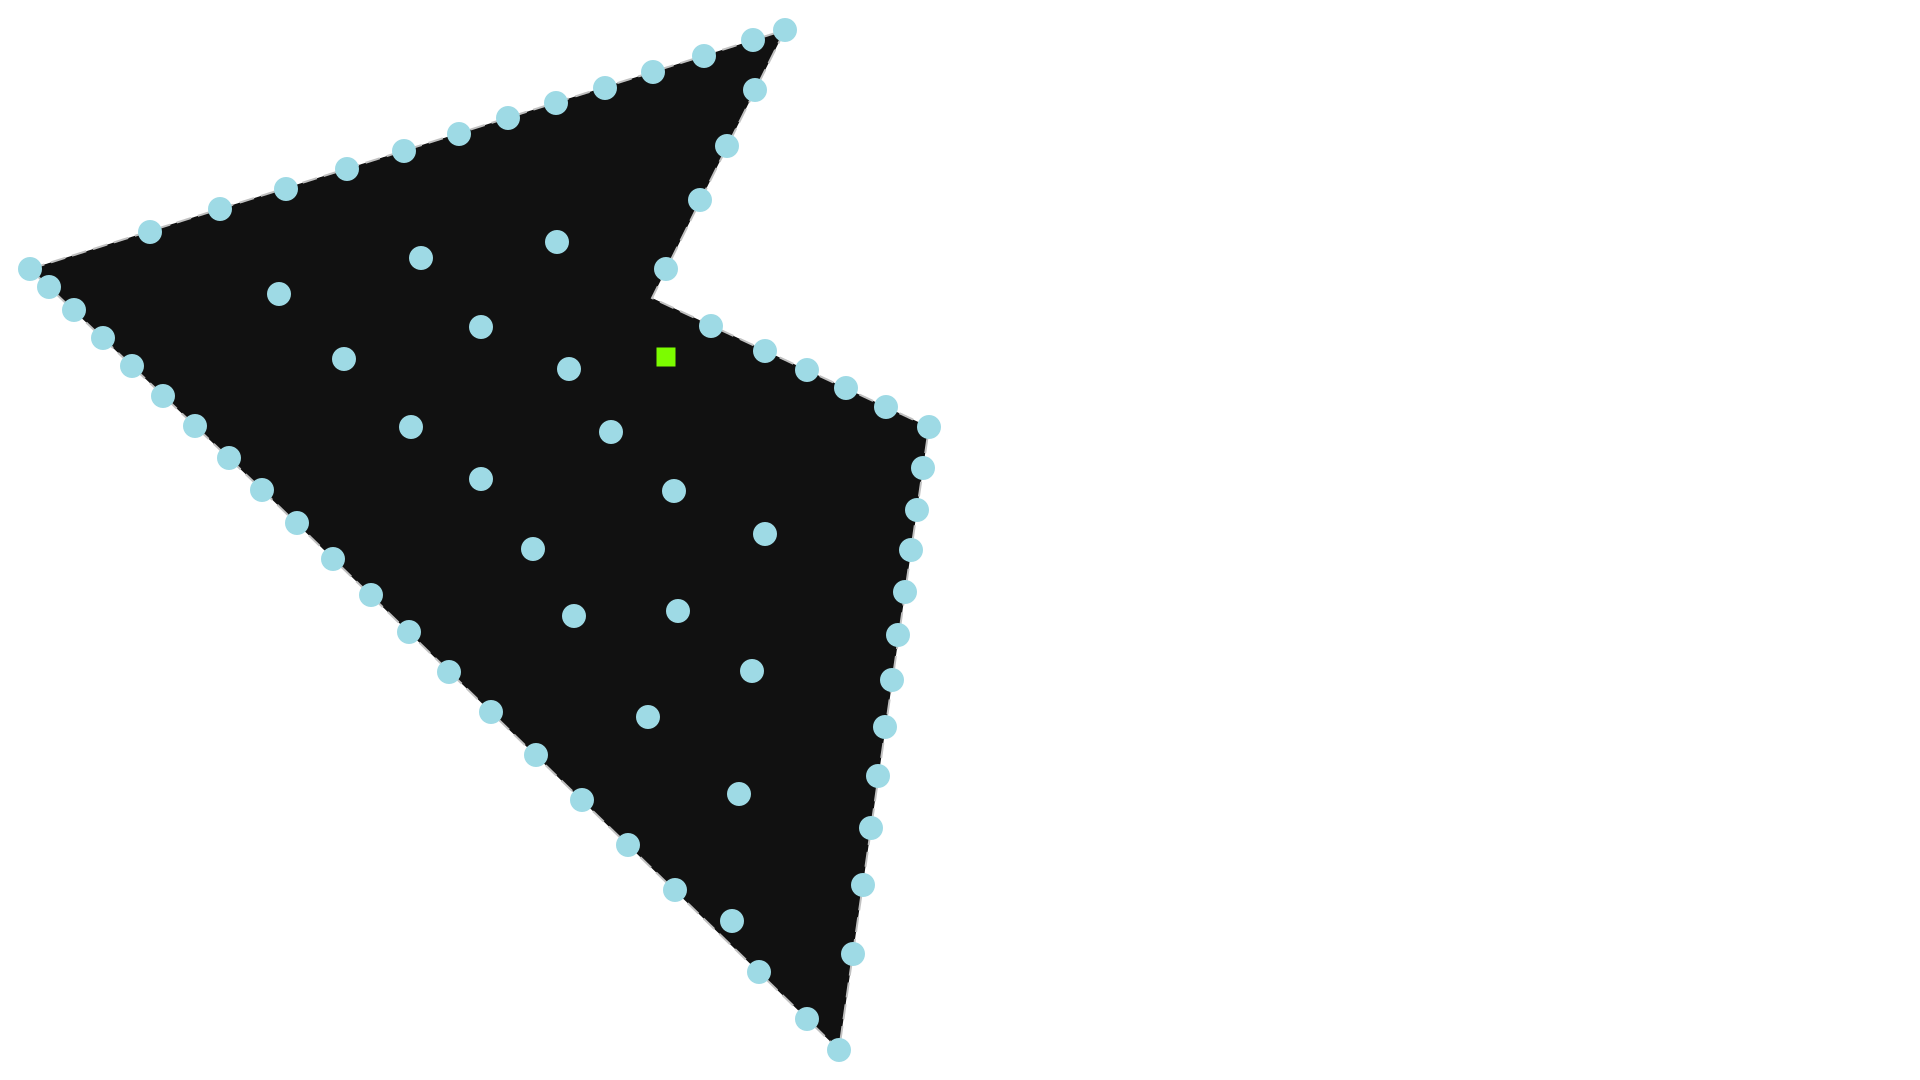

In [7]:
L = L_from_windIO('data/IEA37_Borssele_Irregular_System.yaml')
svgplot(L)

### YAML input file

In [8]:
from optiwindnet.importer import L_from_yaml

The example YAML file is bundled with the source distribution; this notebook reads it without creating or modifying files.

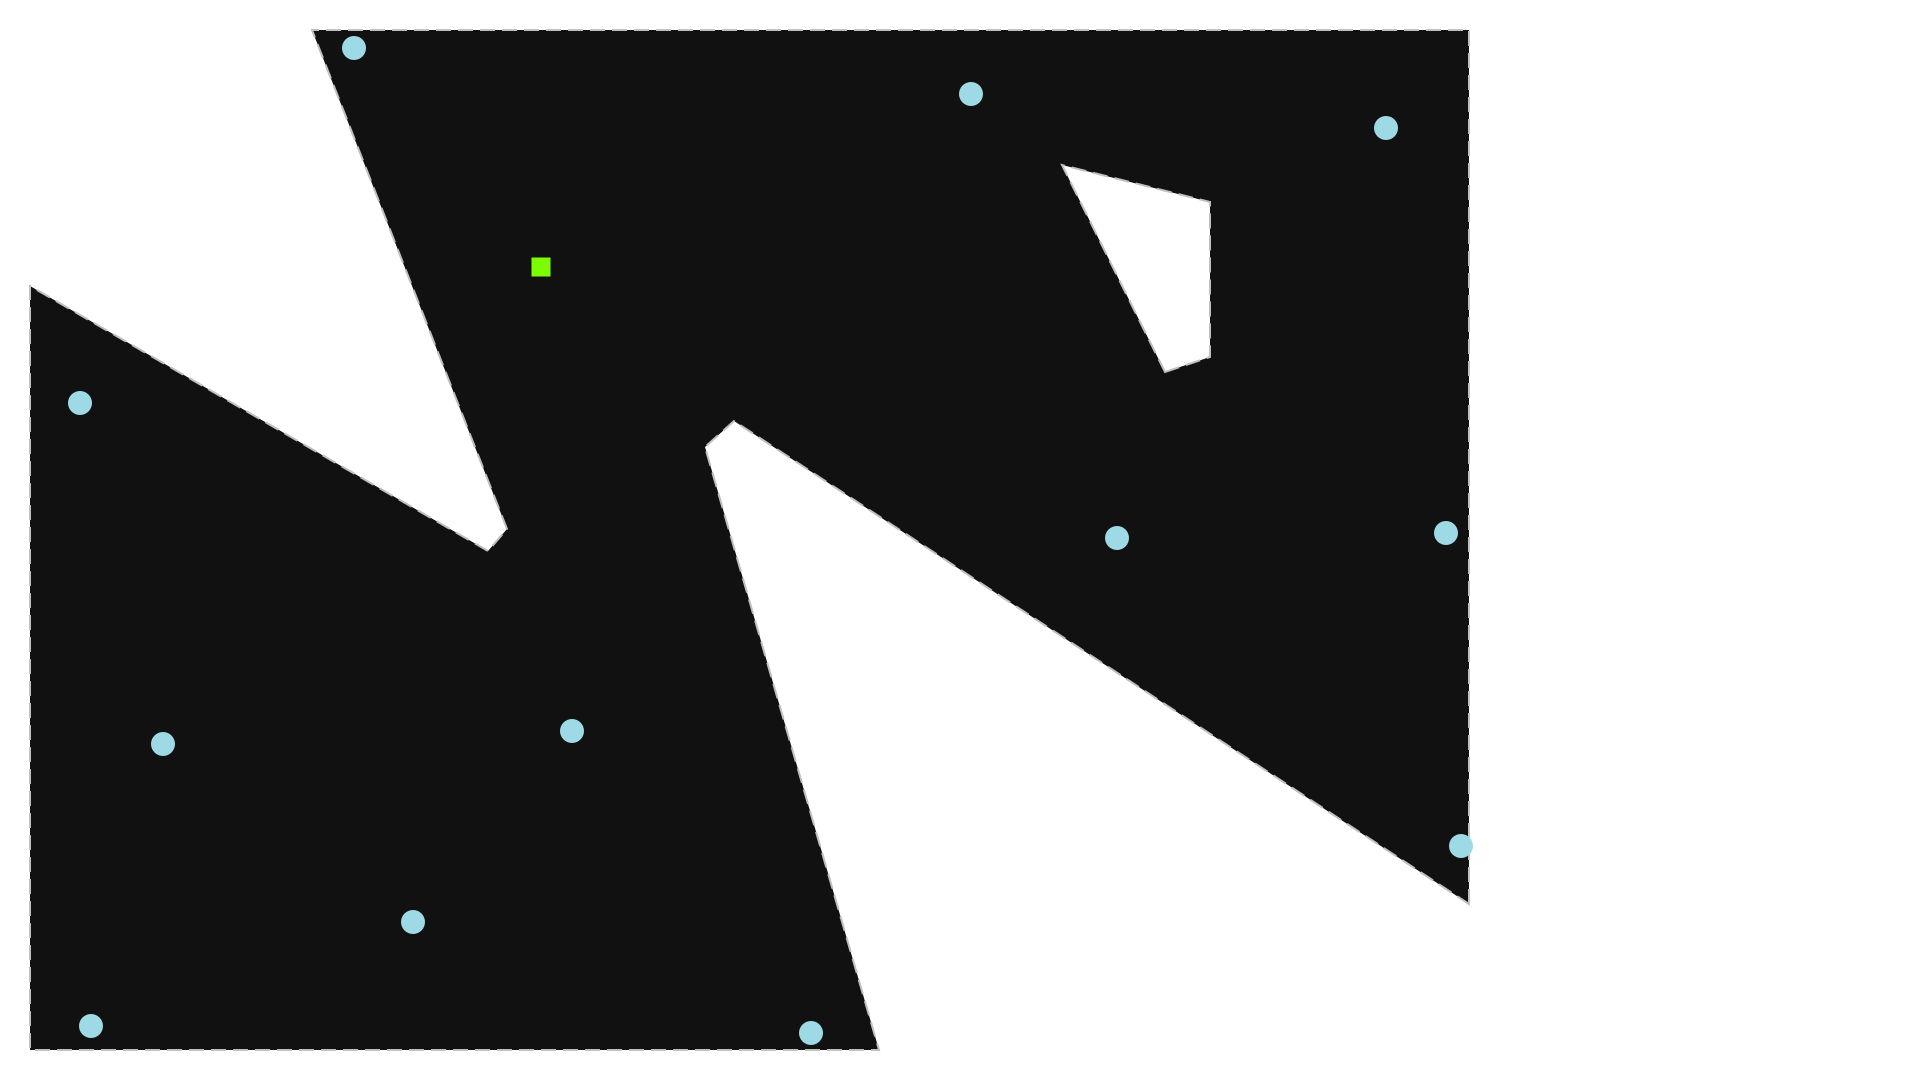

In [9]:
L = L_from_yaml('data/example_location.yaml')
svgplot(L)

### OSM.PBF input file (OpenStreetMap Protobuffer Format)

The JOSM open-source map editor is recommended if using this format: <https://josm.openstreetmap.de/>. In addition, the JOSM plugin **pbf**is required to save in the `.osm.pbf` format. The plugin **opendata**is useful for importing many common GIS file formats.

The OpenStreetMap tagging conventions *OptiWindNet* expects — which tags mark turbines,
substations, the border and the obstacles — are described in
[OpenStreetMap PBF](../data.md#openstreetmap-pbf).

See `optiwindnet/data/*.osm.pbf` for more examples.

In [10]:
from optiwindnet.importer import L_from_pbf

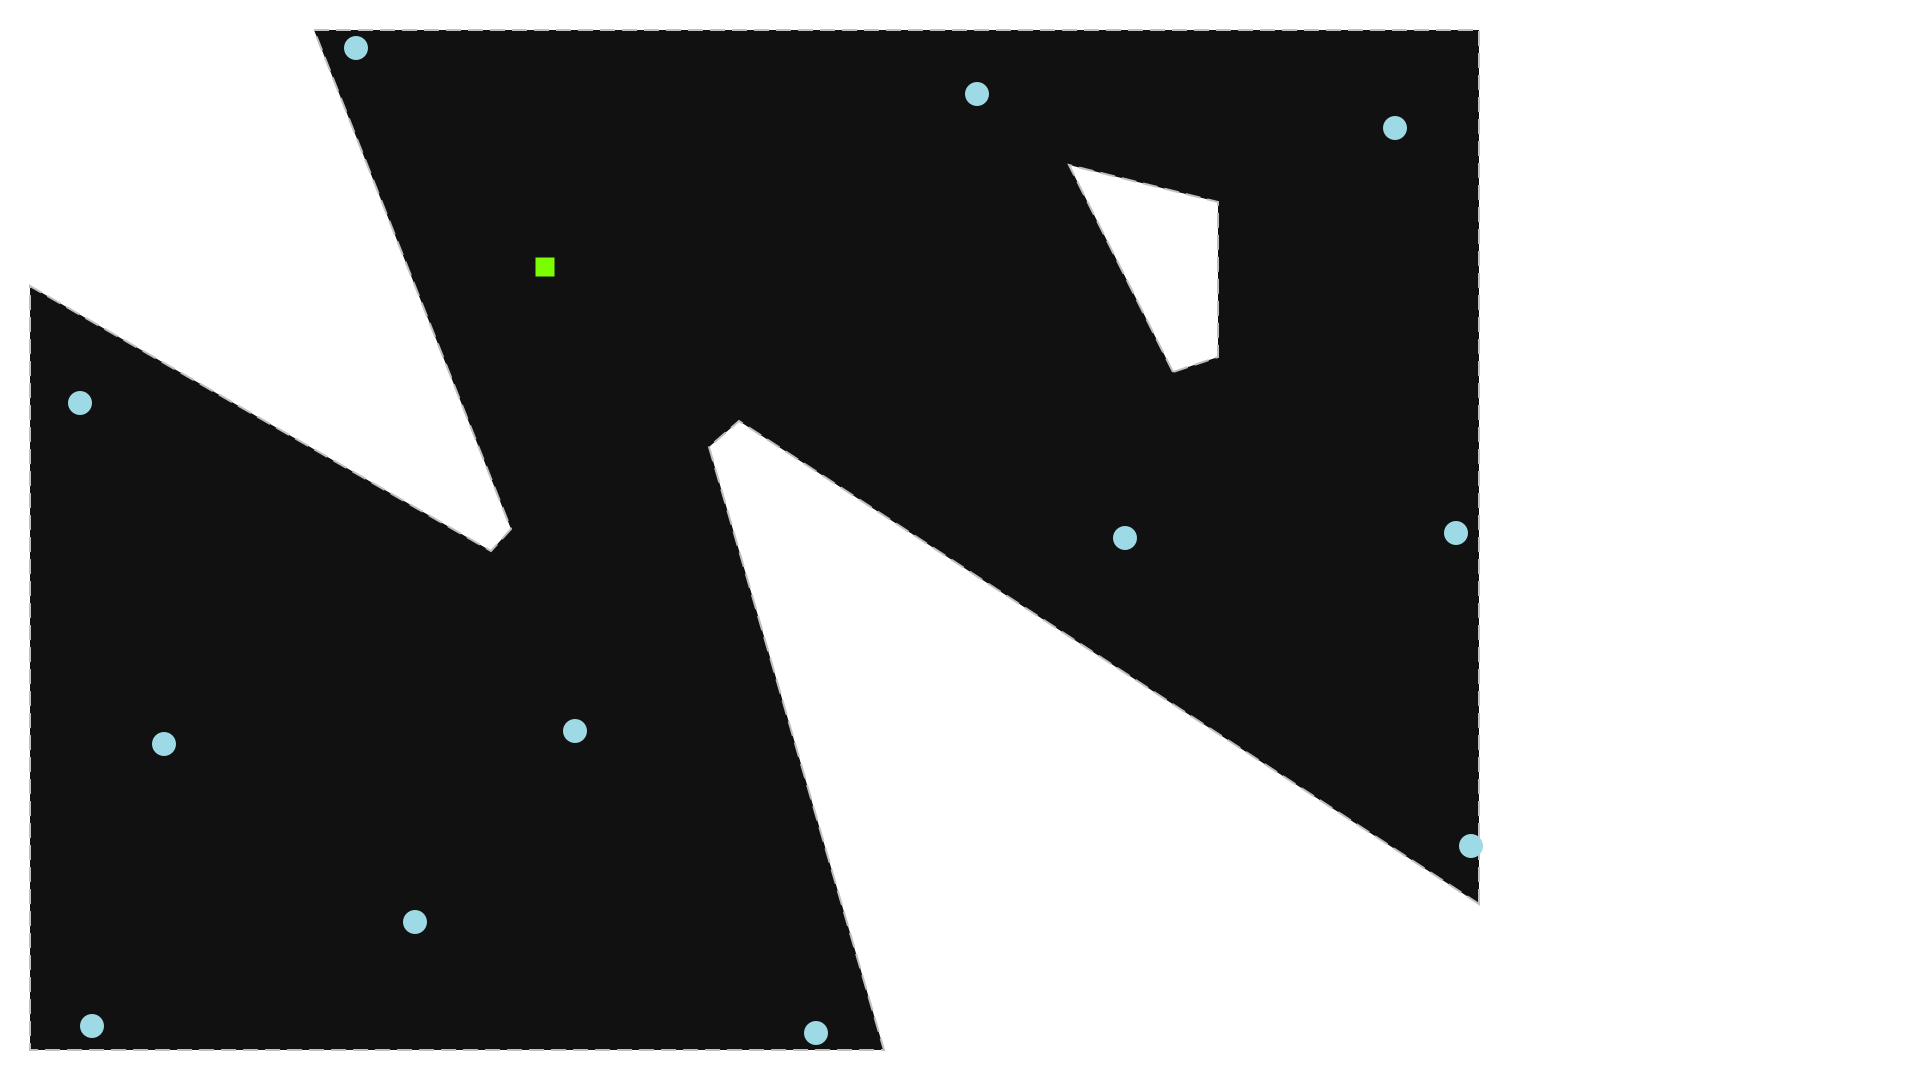

In [11]:
L = L_from_pbf('data/example_location.osm.pbf')
svgplot(L)